In [1]:
# Install and import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
#loading the file
import pandas as pd

df_raw = pd.read_csv("/content/sample_data/Historic_HABs_Events_2015-2023.csv")
df = df_raw.copy()  # keep df for earlier cells

df.head(), df.columns


(             X            Y  OBJECTID             SAMPLE_DATE      TIME  \
 0  524174.4219  393179.5007    396562  2015/02/16 00:00:00+00  15:02:00   
 1  627186.1560  220879.1753    396563  2015/02/16 00:00:00+00  15:33:00   
 2  628350.8443  214141.7306    396564  2015/02/16 00:00:00+00  15:51:00   
 3  635057.4252  216598.3960    396565  2015/02/16 00:00:00+00  16:20:00   
 4  629630.5063  221712.4796    396566  2015/02/16 00:00:00+00  16:40:00   
 
   TIMEZONE  DEPTH                                           LOCATION  \
 0      GMT    0.5  Anna Maria Island Rod & Reel Pier (Lower Tampa...   
 1      GMT    0.5           Lee Avenue; docks NE of (Big Marco Pass)   
 2      GMT    0.5                                      Caxambas Park   
 3      GMT    0.5                                    Goodland Bridge   
 4      GMT    0.5                     951 Boat Ramp (Big Marco Pass)   
 
    LATITUDE  LONGITUDE            NAME  COUNT_          HAB_ID  
 0   27.5385   -82.7402  Karenia bre

In [3]:
# Basic date features
dt = pd.to_datetime(df["SAMPLE_DATE"])

df["date"] = dt.dt.date
df["year"] = dt.dt.year
df["month"] = dt.dt.month
df["dayofyear"] = dt.dt.dayofyear

print(df[["SAMPLE_DATE", "date", "year", "month", "dayofyear"]].head())

              SAMPLE_DATE        date  year  month  dayofyear
0  2015/02/16 00:00:00+00  2015-02-16  2015      2         47
1  2015/02/16 00:00:00+00  2015-02-16  2015      2         47
2  2015/02/16 00:00:00+00  2015-02-16  2015      2         47
3  2015/02/16 00:00:00+00  2015-02-16  2015      2         47
4  2015/02/16 00:00:00+00  2015-02-16  2015      2         47


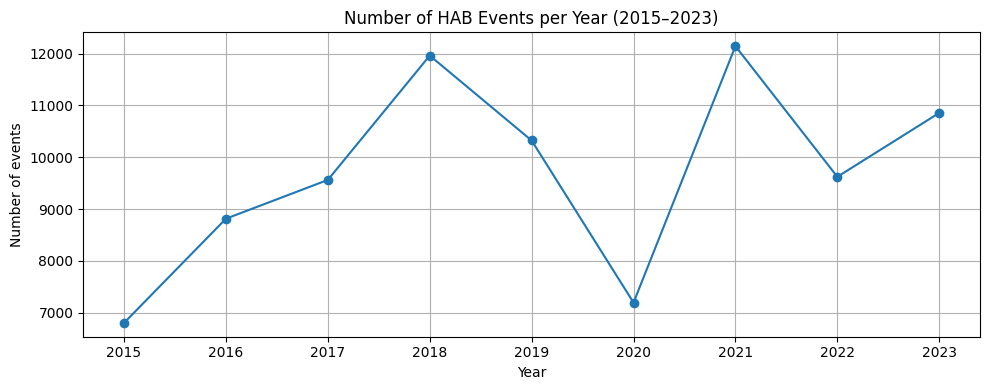

In [4]:
# NUmber of HAB events per year
events_per_year = df.groupby("year").size()

plt.figure(figsize=(10,4))
plt.plot(events_per_year.index, events_per_year.values, marker="o")
plt.title("Number of HAB Events per Year (2015–2023)")
plt.xlabel("Year")
plt.ylabel("Number of events")
plt.grid(True)
plt.tight_layout()
plt.show()

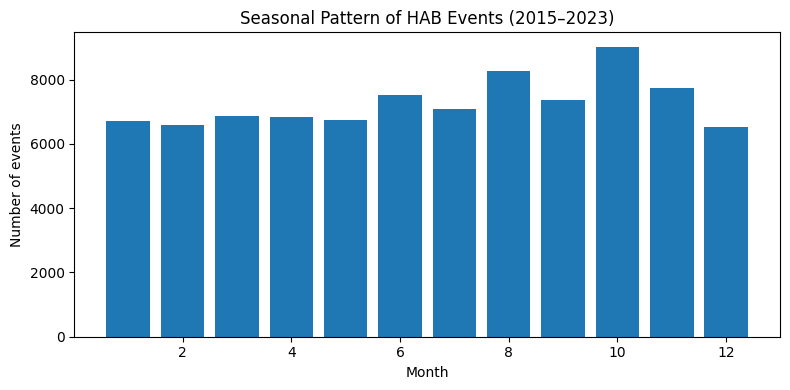

,0
month,
1,6711
2,6603
3,6864
4,6827
5,6747
6,7514
7,7100
8,8261
9,7362


In [5]:
# Seasonal pattern (events per month)
events_per_month = df.groupby("month").size()

plt.figure(figsize=(8,4))
plt.bar(events_per_month.index, events_per_month.values)
plt.title("Seasonal Pattern of HAB Events (2015–2023)")
plt.xlabel("Month")
plt.ylabel("Number of events")
plt.tight_layout()
plt.show()

events_per_month

In [6]:
# Build a daily dataset for modeling
# We’ll aggregate to daily counts, then make a binary label:
# has_event = 1 if that day had ≥1 event, else 0.

# 1. Daily event counts from the original df
daily_counts = (
    df.groupby("date")
      .size()
      .reset_index(name="events")
)

# Ensure daily_counts['date'] is datetime
daily_counts["date"] = pd.to_datetime(daily_counts["date"])

# 2. Full daily date range
full_dates = pd.date_range(
    daily_counts["date"].min(),
    daily_counts["date"].max(),
    freq="D"
)

daily_full = pd.DataFrame({"date": full_dates})

# 3. Merge counts into full calendar
daily_full = daily_full.merge(daily_counts, on="date", how="left")
daily_full["events"] = daily_full["events"].fillna(0)

# 4. Date features again
dt_daily = pd.to_datetime(daily_full["date"])
daily_full["year"] = dt_daily.dt.year
daily_full["month"] = dt_daily.dt.month
daily_full["dayofyear"] = dt_daily.dt.dayofyear

# 5. Binary label: did any HAB event happen this day?
daily_full["has_event"] = (daily_full["events"] > 0).astype(int)

daily_full.head(), daily_full["has_event"].value_counts()

(        date  events  year  month  dayofyear  has_event
 0 2015-01-02     7.0  2015      1          2          1
 1 2015-01-03     0.0  2015      1          3          0
 2 2015-01-04     1.0  2015      1          4          1
 3 2015-01-05    50.0  2015      1          5          1
 4 2015-01-06     5.0  2015      1          6          1,
 has_event
 1    3120
 0     165
 Name: count, dtype: int64)

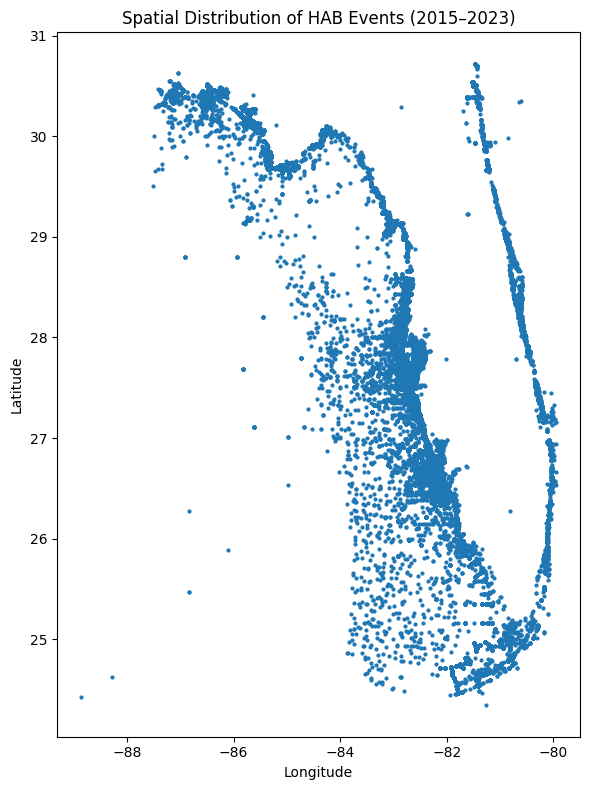

In [7]:
#Spatial distribution (use LATITUDE / LONGITUDE)
plt.figure(figsize=(6,8))
plt.scatter(df["LONGITUDE"], df["LATITUDE"], s=4)
plt.title("Spatial Distribution of HAB Events (2015–2023)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [8]:
# Logistic regression: does month predict HAB-event days?

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# One-hot encode month
X = pd.get_dummies(daily_full["month"], prefix="month", drop_first=True)
y = daily_full["has_event"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.949290060851927

Confusion matrix:
 [[  0  50]
 [  0 936]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.95      1.00      0.97       936

    accuracy                           0.95       986
   macro avg       0.47      0.50      0.49       986
weighted avg       0.90      0.95      0.92       986



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


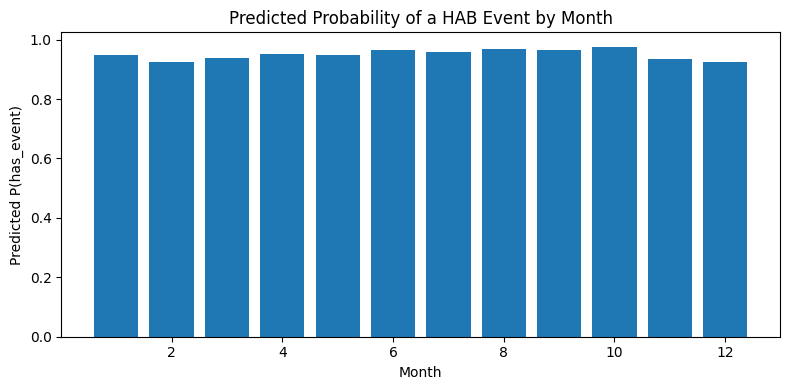

,month,pred_prob
0,1,0.948175
1,2,0.923812
2,3,0.937572
3,4,0.950552
4,5,0.949565
5,6,0.965713
6,7,0.959487
7,8,0.967346
8,9,0.964579
9,10,0.975881


In [9]:
# Predicted probability of an event by month
# Month grid 1..12
month_grid = pd.DataFrame({"month": range(1, 13)})
X_month = pd.get_dummies(month_grid["month"], prefix="month", drop_first=True)

# Align columns with training data
for col in X_train.columns:
    if col not in X_month.columns:
        X_month[col] = 0
X_month = X_month[X_train.columns]

# Predicted probability of has_event = 1
month_grid["pred_prob"] = model.predict_proba(X_month)[:, 1]

plt.figure(figsize=(8,4))
plt.bar(month_grid["month"], month_grid["pred_prob"])
plt.title("Predicted Probability of a HAB Event by Month")
plt.xlabel("Month")
plt.ylabel("Predicted P(has_event)")
plt.tight_layout()
plt.show()

month_grid

In [10]:
# Because of the imbalace data, we want look more closely and restricting to one region which is Sarasota bay
# filter datasets
df_sarasota = df[df["LOCATION"].str.contains("Sarasota", case=False, na=False)]
df_sarasota.head(), df_sarasota.shape

(             X            Y  OBJECTID             SAMPLE_DATE TIME TIMEZONE  \
 5  540804.7940  372828.3420    396567  2015/02/03 00:00:00+00  NaN      GMT   
 6  541543.7877  371434.3578    396568  2015/02/03 00:00:00+00  NaN      GMT   
 7  540227.1395  370686.2004    396569  2015/02/03 00:00:00+00  NaN      GMT   
 8  541807.7317  368018.2397    396570  2015/02/03 00:00:00+00  NaN      GMT   
 9  542607.1506  367741.0693    396571  2015/02/03 00:00:00+00  NaN      GMT   
 
    DEPTH                           LOCATION  LATITUDE  LONGITUDE  \
 5    1.0   City Island; N of (Sarasota Bay)  27.35361  -82.57388   
 6    1.0  City Island; NE of (Sarasota Bay)  27.34098  -82.56656   
 7    1.0            New Pass (Sarasota Bay)  27.33438  -82.57998   
 8    1.0      Bird Key; W of (Sarasota Bay)  27.31019  -82.56429   
 9    1.0    Bay Island; N of (Sarasota Bay)  27.30761  -82.55623   
 
              NAME  COUNT_          HAB_ID        date  year  month  dayofyear  
 5  Karenia brevis   

In [11]:
# Create daily counts again
daily_counts = (
    df_sarasota.groupby("date")
      .size()
      .reset_index(name="events")
)

daily_counts["date"] = pd.to_datetime(daily_counts["date"])

full_dates = pd.date_range(daily_counts["date"].min(),
                           daily_counts["date"].max(), freq="D")

daily_full = pd.DataFrame({"date": full_dates})
daily_full = daily_full.merge(daily_counts, on="date", how="left")
daily_full["events"] = daily_full["events"].fillna(0)

# Features
dt = pd.to_datetime(daily_full["date"])
daily_full["month"] = dt.dt.month

# Target for modeling
daily_full["has_event"] = (daily_full["events"] > 0).astype(int)

daily_full["has_event"].value_counts()

,count
has_event,
1,1891
0,1393


In [12]:
# Re running the logistic regreesion on Sarasota Bay Subset

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features & target
X = pd.get_dummies(daily_full["month"], prefix="month", drop_first=True)
y = daily_full["has_event"]

# Stratified split since classes are now balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5760649087221096

Confusion matrix:
 [[  0 418]
 [  0 568]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       418
           1       0.58      1.00      0.73       568

    accuracy                           0.58       986
   macro avg       0.29      0.50      0.37       986
weighted avg       0.33      0.58      0.42       986



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


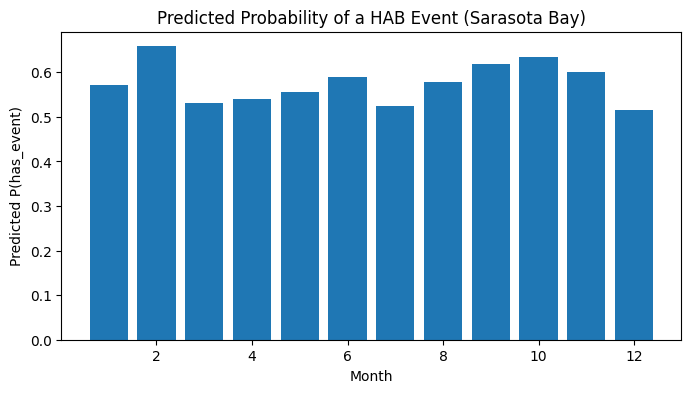

,month,pred_prob
0,1,0.571188
1,2,0.658060
2,3,0.530213
3,4,0.540011
4,5,0.555190
5,6,0.589083
6,7,0.523492
7,8,0.578755
8,9,0.618351
9,10,0.634547


In [13]:
# Predicted probability by month

month_grid = pd.DataFrame({"month": range(1, 13)})
X_month = pd.get_dummies(month_grid["month"], prefix="month", drop_first=True)

# Align columns
for col in X_train.columns:
    if col not in X_month.columns:
        X_month[col] = 0
X_month = X_month[X_train.columns]

month_grid["pred_prob"] = model.predict_proba(X_month)[:, 1]

plt.figure(figsize=(8,4))
plt.bar(month_grid["month"], month_grid["pred_prob"])
plt.title("Predicted Probability of a HAB Event (Sarasota Bay)")
plt.xlabel("Month")
plt.ylabel("Predicted P(has_event)")
plt.show()

month_grid

In [15]:
# Random Forest
# set up shared features fo random forest
# make sure date is datetime
daily_full["date"] = pd.to_datetime(daily_full["date"])

# add day-of-year feature
daily_full["dayofyear"] = daily_full["date"].dt.dayofyear

daily_full[["date", "month", "dayofyear"]].head()



,date,month,dayofyear
0,2015-01-02,1,2
1,2015-01-03,1,3
2,2015-01-04,1,4
3,2015-01-05,1,5
4,2015-01-06,1,6


In [16]:
# FEATURE MATRIX
X_month = pd.get_dummies(daily_full["month"], prefix="month", drop_first=True)
X = pd.concat([X_month, daily_full[["dayofyear"]]], axis=1)

# TARGET
y = daily_full["has_event"]

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [17]:
# Random Forest model (Baseline 2)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.4918864097363083

Confusion matrix:
 [[141 277]
 [224 344]]

Classification report:
               precision    recall  f1-score   support

           0       0.39      0.34      0.36       418
           1       0.55      0.61      0.58       568

    accuracy                           0.49       986
   macro avg       0.47      0.47      0.47       986
weighted avg       0.48      0.49      0.49       986



In [18]:
#Re-create the Sarasota daily dataset
# 1. Filter Sarasota-only rows
sarasota_df = df[df["LOCATION"].str.contains("Sarasota", case=False, na=False)].copy()

# 2. Create date column
sarasota_df["date"] = pd.to_datetime(sarasota_df["SAMPLE_DATE"])

# 3. Daily event count
daily_sara = sarasota_df.groupby("date").size().reset_index(name="events")

# 4. Create full date range
full_dates = pd.date_range(daily_sara["date"].min(), daily_sara["date"].max(), freq="D")
daily_full = pd.DataFrame({"date": full_dates})

# 5. Merge & fill missing days
daily_full = daily_full.merge(daily_sara, on="date", how="left")
daily_full["events"] = daily_full["events"].fillna(0)

# 6. Feature engineering
daily_full["month"] = daily_full["date"].dt.month
daily_full["dayofyear"] = daily_full["date"].dt.dayofyear
daily_full["has_event"] = (daily_full["events"] > 0).astype(int)

daily_full.head()

,date,events,month,dayofyear,has_event
0,2015-01-02 00:00:00+00:00,2.0,1,2,1
1,2015-01-03 00:00:00+00:00,0.0,1,3,0
2,2015-01-04 00:00:00+00:00,0.0,1,4,0
3,2015-01-05 00:00:00+00:00,3.0,1,5,1
4,2015-01-06 00:00:00+00:00,2.0,1,6,1


In [19]:
#Sample of daily aggregated HAB dataset (table)
daily_full.head()

,date,events,month,dayofyear,has_event
0,2015-01-02 00:00:00+00:00,2.0,1,2,1
1,2015-01-03 00:00:00+00:00,0.0,1,3,0
2,2015-01-04 00:00:00+00:00,0.0,1,4,0
3,2015-01-05 00:00:00+00:00,3.0,1,5,1
4,2015-01-06 00:00:00+00:00,2.0,1,6,1


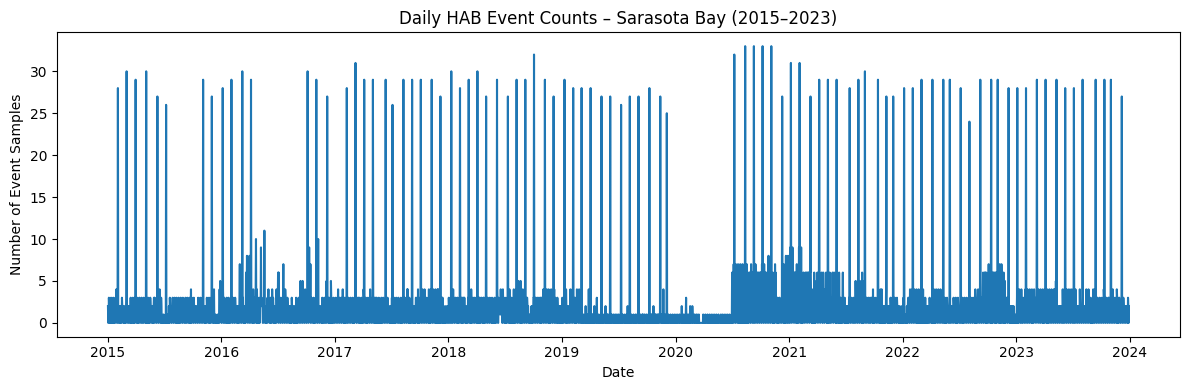

In [20]:
#Daily time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(daily_full["date"], daily_full["events"])
plt.title("Daily HAB Event Counts – Sarasota Bay (2015–2023)")
plt.xlabel("Date")
plt.ylabel("Number of Event Samples")
plt.tight_layout()
plt.show()

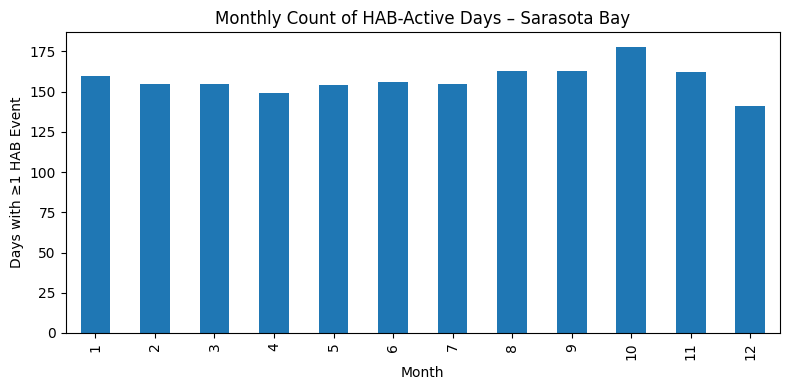

In [21]:
#Monthly distribution (Bar chart)
monthly_counts = daily_full.groupby("month")["has_event"].sum()

plt.figure(figsize=(8,4))
monthly_counts.plot(kind="bar")
plt.title("Monthly Count of HAB-Active Days – Sarasota Bay")
plt.xlabel("Month")
plt.ylabel("Days with ≥1 HAB Event")
plt.tight_layout()
plt.show()

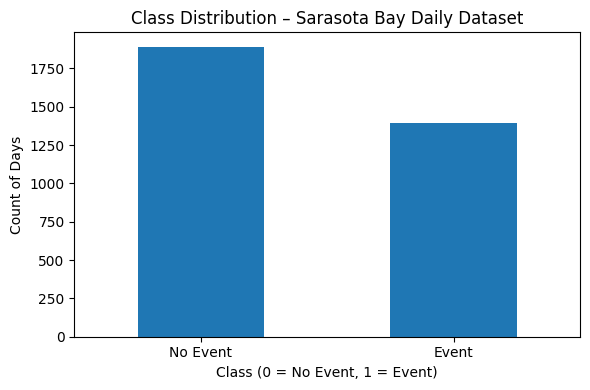

In [22]:
# Class distribution (0 vs 1)
daily_full["has_event"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Class Distribution – Sarasota Bay Daily Dataset")
plt.xlabel("Class (0 = No Event, 1 = Event)")
plt.ylabel("Count of Days")
plt.xticks([0,1], ["No Event","Event"], rotation=0)
plt.tight_layout()
plt.show()

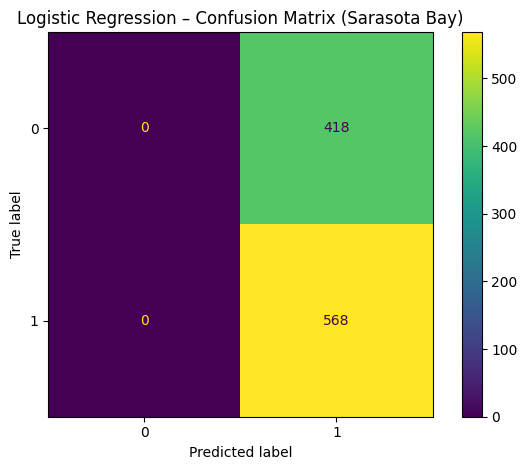

In [23]:
# logistic regression confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression – Confusion Matrix (Sarasota Bay)")
plt.tight_layout()
plt.show()

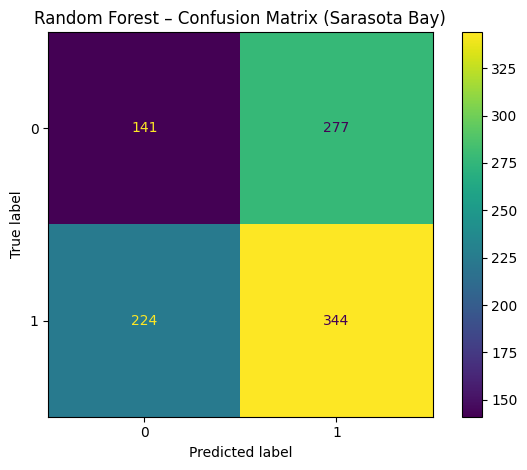

In [24]:
# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest – Confusion Matrix (Sarasota Bay)")
plt.tight_layout()
plt.show()

In [25]:
#using enviornmental data
import pandas as pd

sst = pd.read_csv("/content/sample_data/sst_sarasota.csv")

col = sst.columns[0]   # the first column is the timestamp

sst[col] = pd.to_datetime(sst[col], errors="coerce")
sst = sst.rename(columns={col: "date"})

sst.head()

/tmp/ipykernel_8094/446394548.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sst[col] = pd.to_datetime(sst[col], errors="coerce")


,date,zlev,latitude,longitude,sst
0,NaT,m,degrees_north,degrees_east,degree_C
1,2015-01-01 12:00:00+00:00,0.0,27.125,277.375,20.93
2,2015-01-02 12:00:00+00:00,0.0,27.125,277.375,21.19
3,2015-01-03 12:00:00+00:00,0.0,27.125,277.375,21.29
4,2015-01-04 12:00:00+00:00,0.0,27.125,277.375,21.42


In [26]:
sst = sst.dropna(subset=["date"]).reset_index(drop=True)
sst.head()

,date,zlev,latitude,longitude,sst
0,2015-01-01 12:00:00+00:00,0.0,27.125,277.375,20.93
1,2015-01-02 12:00:00+00:00,0.0,27.125,277.375,21.19
2,2015-01-03 12:00:00+00:00,0.0,27.125,277.375,21.29
3,2015-01-04 12:00:00+00:00,0.0,27.125,277.375,21.42
4,2015-01-05 12:00:00+00:00,0.0,27.125,277.375,21.41


In [27]:
import pandas as pd

# Load HAB dataset
df = pd.read_csv("/content/sample_data/Historic_HABs_Events_2015-2023.csv")
df.head()
# Filter Sarasota-only rows
sarasota_df = df[df["LOCATION"].str.contains("Sarasota", case=False, na=False)].copy()
sarasota_df.head()
sarasota_df["date"] = pd.to_datetime(sarasota_df["SAMPLE_DATE"])
daily_sara = sarasota_df.groupby("date").size().reset_index(name="events")
daily_sara.head()
full_dates = pd.date_range(
    start=daily_sara["date"].min(),
    end=daily_sara["date"].max(),
    freq="D"
)

daily_full = pd.DataFrame({"date": full_dates})
daily_full = daily_full.merge(daily_sara, on="date", how="left")
daily_full["events"] = daily_full["events"].fillna(0)
daily_full["month"] = daily_full["date"].dt.month
daily_full["dayofyear"] = daily_full["date"].dt.dayofyear
daily_full["has_event"] = (daily_full["events"] > 0).astype(int)
merged = daily_full.merge(sst[["date", "sst"]], on="date", how="left")
merged.head()

,date,events,month,dayofyear,has_event,sst
0,2015-01-02 00:00:00+00:00,2.0,1,2,1,NaN
1,2015-01-03 00:00:00+00:00,0.0,1,3,0,NaN
2,2015-01-04 00:00:00+00:00,0.0,1,4,0,NaN
3,2015-01-05 00:00:00+00:00,3.0,1,5,1,NaN
4,2015-01-06 00:00:00+00:00,2.0,1,6,1,NaN


In [28]:
#Helper function to clean Giovanni time-series CSVs
import pandas as pd

# path assumes your notebook is in the same folder that contains the "Data" folder
DATA_DIR = "sample_data"

def clean_giovanni_timeseries(filename, value_name):
    """
    filename   : CSV file name inside the Data folder
    value_name : how you want to name the numeric column (e.g. 'chl_a', 'kd490')
    """
    path = f"{DATA_DIR}/{filename}"

    # Read without header so we can find where the real header is
    raw = pd.read_csv(path, header=None)

    # Find the row index where the first column is exactly 'time'
    header_idx = raw.index[raw[0] == "time"][0]

    # Data starts on the next row; keep only the first two columns (time + value)
    data = raw.iloc[header_idx + 1:, [0, 1]].copy()
    data.columns = ["date", value_name]

    # Convert to proper types
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data[value_name] = pd.to_numeric(data[value_name], errors="coerce")

    # Drop any rows where date is missing
    data = data.dropna(subset=["date"]).reset_index(drop=True)

    # Get rid of any timezone info just in case
    data["date"] = data["date"].dt.tz_localize(None)

    return data

In [29]:
# Clean chlorophyll-a time series
chl = clean_giovanni_timeseries("chl_a_FL_2018_2023.csv", "chl_a")
chl.head()

,date,chl_a
0,2018-01-01,3.290678
1,2018-02-01,2.112855
2,2018-03-01,1.836619
3,2018-04-01,1.492735
4,2018-05-01,1.252793


In [30]:
# Clean KD490 time series
kd = clean_giovanni_timeseries("kd490_FL_2018_2023.csv", "kd490")
kd.head()

,date,kd490
0,2018-01-01,0.253386
1,2018-02-01,0.165948
2,2018-03-01,0.150222
3,2018-04-01,0.128710
4,2018-05-01,0.115281


In [31]:
# Convert to daily frequency with forward-fill
chl_daily = (
    chl.set_index("date")
       .resample("D")
       .ffill()
       .reset_index()
)

kd_daily = (
    kd.set_index("date")
      .resample("D")
      .ffill()
      .reset_index()
)

chl_daily.head(), kd_daily.head()

(        date     chl_a
 0 2018-01-01  3.290678
 1 2018-01-02  3.290678
 2 2018-01-03  3.290678
 3 2018-01-04  3.290678
 4 2018-01-05  3.290678,
         date     kd490
 0 2018-01-01  0.253386
 1 2018-01-02  0.253386
 2 2018-01-03  0.253386
 3 2018-01-04  0.253386
 4 2018-01-05  0.253386)

In [32]:
# Clean SST and aggregate to daily
import pandas as pd

# Load SST
sst_raw = pd.read_csv("sample_data/sst_sarasota.csv")

# Drop the units row (where time == "UTC")
sst = sst_raw[sst_raw["time"] != "UTC"].copy()

# Parse time and convert to daily date
sst["date"] = pd.to_datetime(sst["time"], errors="coerce")
sst["date"] = sst["date"].dt.floor("D")   # strip time-of-day

# Keep only the SST column and convert to numeric
sst["sst"] = pd.to_numeric(sst["sst"], errors="coerce")

# Daily mean SST (just in case there are multiple times per day)
sst_daily = (
    sst.groupby("date", as_index=False)["sst"]
       .mean()
       .sort_values("date")
)

print(sst_daily.head())
print("SST daily shape:", sst_daily.shape)

                       date    sst
0 2015-01-01 00:00:00+00:00  20.93
1 2015-01-02 00:00:00+00:00  21.19
2 2015-01-03 00:00:00+00:00  21.29
3 2015-01-04 00:00:00+00:00  21.42
4 2015-01-05 00:00:00+00:00  21.41
SST daily shape: (3283, 2)


In [33]:
#Normalize ALL date columns to the same type
def make_naive_date(df, col="date"):
    # Parse as datetime with UTC, then drop timezone
    df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")
    df[col] = df[col].dt.tz_convert(None)
    return df

# Apply to ALL relevant dataframes
daily_full = make_naive_date(daily_full, "date")
sst_daily  = make_naive_date(sst_daily,  "date")
chl_daily  = make_naive_date(chl_daily,  "date")
kd_daily   = make_naive_date(kd_daily,   "date")

print("daily_full date dtype:", daily_full["date"].dtype)
print("sst_daily   date dtype:", sst_daily["date"].dtype)
print("chl_daily   date dtype:", chl_daily["date"].dtype)
print("kd_daily    date dtype:", kd_daily["date"].dtype)

daily_full date dtype: datetime64[ns]
sst_daily   date dtype: datetime64[ns]
chl_daily   date dtype: datetime64[ns]
kd_daily    date dtype: datetime64[ns]


In [34]:
# Rebuild daily_full from full Sarasota date range, then merge
import pandas as pd

# Step 1: Rebuild Sarasota daily covering full 2015-2023 range
sarasota_df2 = df_raw[df_raw["LOCATION"].str.contains("Sarasota", case=False, na=False)].copy()
sarasota_df2["date"] = pd.to_datetime(sarasota_df2["SAMPLE_DATE"]).dt.tz_convert(None)

daily_sara2 = sarasota_df2.groupby("date").size().reset_index(name="events")

full_dates2 = pd.date_range(daily_sara2["date"].min(), daily_sara2["date"].max(), freq="D")
daily_rebuilt = pd.DataFrame({"date": full_dates2})
daily_rebuilt = daily_rebuilt.merge(daily_sara2, on="date", how="left")
daily_rebuilt["events"]    = daily_rebuilt["events"].fillna(0)
daily_rebuilt["month"]     = daily_rebuilt["date"].dt.month
daily_rebuilt["dayofyear"] = daily_rebuilt["date"].dt.dayofyear
daily_rebuilt["has_event"] = (daily_rebuilt["events"] > 0).astype(int)

print("daily_rebuilt shape:", daily_rebuilt.shape)
print("date range:", daily_rebuilt["date"].min(), "→", daily_rebuilt["date"].max())

# Step 2: Strip timezone from all env frames
def strip_tz(frame):
    f = frame.copy()
    f["date"] = pd.to_datetime(f["date"])
    if f["date"].dt.tz is not None:
        f["date"] = f["date"].dt.tz_convert(None)
    return f

sst_c = strip_tz(sst_daily)
chl_c = strip_tz(chl_daily)
kd_c  = strip_tz(kd_daily)

# Step 3: Merge all env data
merged = daily_rebuilt.copy()
merged = merged.merge(sst_c, on="date", how="left")
merged = merged.merge(chl_c, on="date", how="left")
merged = merged.merge(kd_c,  on="date", how="left")
merged = merged.sort_values("date").reset_index(drop=True)

print("\nmerged shape:", merged.shape)
print("NA counts in env cols:\n", merged[["sst","chl_a","kd490"]].isna().sum())
print("\nSample from 2018:")
print(merged[merged["date"] >= "2018-01-01"].head())


daily_rebuilt shape: (3284, 5)
date range: 2015-01-02 00:00:00 → 2023-12-29 00:00:00

merged shape: (3284, 8)
NA counts in env cols:
 sst         4
chl_a    1123
kd490    1123
dtype: int64

Sample from 2018:
           date  events  month  dayofyear  has_event    sst     chl_a  \
1095 2018-01-01     0.0      1          1          0  20.96  3.290678   
1096 2018-01-02     3.0      1          2          1  19.95  3.290678   
1097 2018-01-03     2.0      1          3          1  19.06  3.290678   
1098 2018-01-04     2.0      1          4          1  18.92  3.290678   
1099 2018-01-05     2.0      1          5          1  19.12  3.290678   

         kd490  
1095  0.253386  
1096  0.253386  
1097  0.253386  
1098  0.253386  
1099  0.253386  


In [35]:
# Filter to 2018+ where all env data exists, forward-fill satellite gaps
df_merged = merged[merged["date"] >= "2018-01-01"].copy()
df_merged[["sst","chl_a","kd490"]] = df_merged[["sst","chl_a","kd490"]].ffill()
df_merged = df_merged.dropna().reset_index(drop=True)

print("df_merged shape:", df_merged.shape)
print("date range:", df_merged["date"].min(), "→", df_merged["date"].max())
df_merged.head()


df_merged shape: (2189, 8)
date range: 2018-01-01 00:00:00 → 2023-12-29 00:00:00


,date,events,month,dayofyear,has_event,sst,chl_a,kd490
0,2018-01-01,0.0,1,1,0,20.96,3.290678,0.253386
1,2018-01-02,3.0,1,2,1,19.95,3.290678,0.253386
2,2018-01-03,2.0,1,3,1,19.06,3.290678,0.253386
3,2018-01-04,2.0,1,4,1,18.92,3.290678,0.253386
4,2018-01-05,2.0,1,5,1,19.12,3.290678,0.253386


In [36]:
# df alias for downstream compatibility
df = df_merged.copy()
print("df shape:", df.shape)
df.head()


df shape: (2189, 8)


,date,events,month,dayofyear,has_event,sst,chl_a,kd490
0,2018-01-01,0.0,1,1,0,20.96,3.290678,0.253386
1,2018-01-02,3.0,1,2,1,19.95,3.290678,0.253386
2,2018-01-03,2.0,1,3,1,19.06,3.290678,0.253386
3,2018-01-04,2.0,1,4,1,18.92,3.290678,0.253386
4,2018-01-05,2.0,1,5,1,19.12,3.290678,0.253386


## Phase 1 — Calendar-Based Prediction
The earlier section (above) explored whether HAB events in Sarasota Bay could be predicted using **calendar/temporal structure alone** (month, day-of-year) as baseline models.

---

## Phase 2 — Environmental Variables + Lag History + Multi-Day Forecasting
This section extends the hypothesis by:
1. Incorporating **environmental predictors** (SST, chlorophyll-a, KD490)
2. Adding a **20-day lag window** of recent bloom history
3. Evaluating **1-day, 2-day, and 3-day ahead forecasting** to assess how far in advance a bloom can be reliably predicted

In [37]:
print("df shape:", df.shape)
print("date range:", df["date"].min(), "→", df["date"].max())


df shape: (2189, 8)
date range: 2018-01-01 00:00:00 → 2023-12-29 00:00:00


In [38]:
# Feature Engineering: lags 1–20 + cyclical encoding
import numpy as np
import pandas as pd

df_fe = df_merged.copy()

# Day-of-week
df_fe["dow"] = df_fe["date"].dt.weekday

# Cyclical day-of-year encoding
df_fe["sin_doy"] = np.sin(2 * np.pi * df_fe["dayofyear"] / 365.25)
df_fe["cos_doy"] = np.cos(2 * np.pi * df_fe["dayofyear"] / 365.25)

# Lag features: previous 1–20 days of bloom history
for lag in range(1, 21):
    df_fe[f"lag_event_{lag}"] = df_fe["has_event"].shift(lag)

lag_feature_cols = [f"lag_event_{lag}" for lag in range(1, 21)]
env_cols         = ["sst", "chl_a", "kd490"]
calendar_cols    = ["month", "dow", "sin_doy", "cos_doy"]
feature_cols     = env_cols + calendar_cols + lag_feature_cols

df_fe = df_fe.dropna(subset=feature_cols + ["has_event"]).reset_index(drop=True)

print("df_fe shape:", df_fe.shape)
print("Features:", feature_cols)


df_fe shape: (2169, 31)
Features: ['sst', 'chl_a', 'kd490', 'month', 'dow', 'sin_doy', 'cos_doy', 'lag_event_1', 'lag_event_2', 'lag_event_3', 'lag_event_4', 'lag_event_5', 'lag_event_6', 'lag_event_7', 'lag_event_8', 'lag_event_9', 'lag_event_10', 'lag_event_11', 'lag_event_12', 'lag_event_13', 'lag_event_14', 'lag_event_15', 'lag_event_16', 'lag_event_17', 'lag_event_18', 'lag_event_19', 'lag_event_20']


In [39]:
print("df_fe shape:", df_fe.shape)
print(df_fe[feature_cols + ["has_event"]].isna().sum())

df_fe shape: (2169, 31)
sst             0
chl_a           0
kd490           0
month           0
dow             0
sin_doy         0
cos_doy         0
lag_event_1     0
lag_event_2     0
lag_event_3     0
lag_event_4     0
lag_event_5     0
lag_event_6     0
lag_event_7     0
lag_event_8     0
lag_event_9     0
lag_event_10    0
lag_event_11    0
lag_event_12    0
lag_event_13    0
lag_event_14    0
lag_event_15    0
lag_event_16    0
lag_event_17    0
lag_event_18    0
lag_event_19    0
lag_event_20    0
has_event       0
dtype: int64


### Multi-Day Forecasting Strategy
Instead of predicting whether a bloom occurs **today** (same-day target), we shift the target forward:
- **1-day ahead**: predict bloom at `t+1` using features at `t`
- **2-day ahead**: predict bloom at `t+2` using features at `t`
- **3-day ahead**: predict bloom at `t+3` using features at `t`

The feature set (environmental + lag history) stays the same for all horizons.

## Phase 2 — Model Evaluation with 70/10/20 Chronological Split

All four models are evaluated under an identical setup:
- **Train (70%)**: model fitting
- **Validation (10%)**: used for early stopping (LSTM) and hyperparameter reference
- **Test (20%)**: final reported performance — never seen during training

This ensures reported metrics reflect true generalisation to unseen future data.

In [42]:
# All Four Models — 2-Day Ahead | 70 / 10 / 20 Chronological Split
# 70% train | 10% validation (hyperparameter reference) | 20% test (final eval)
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, accuracy_score,
                              precision_recall_fscore_support)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HORIZON = 2   # Primary forecast horizon

# Build dataset for this horizon
df_h = df_fe.copy()
df_h["target_future"] = df_h["has_event"].shift(-HORIZON)
df_h = df_h.dropna(subset=feature_cols + ["target_future"]).reset_index(drop=True)

X_all = df_h[feature_cols]
y_all = df_h["target_future"].astype(int)
n     = len(df_h)

# 70 / 10 / 20 chronological split
train_end = int(n * 0.70)
val_end   = int(n * 0.80)   # 70+10 = 80% boundary

X_tr,  y_tr  = X_all.iloc[:train_end],  y_all.iloc[:train_end]
X_val, y_val = X_all.iloc[train_end:val_end], y_all.iloc[train_end:val_end]
X_te,  y_te  = X_all.iloc[val_end:],    y_all.iloc[val_end:]

test_dates = df_h["date"].iloc[val_end:].reset_index(drop=True)

print(f"Dataset: {n} rows | Horizon: {HORIZON}-day ahead")
print(f"Train : rows 0–{train_end-1}  ({len(X_tr)} days)  "
      f"{df_h['date'].iloc[0].date()} → {df_h['date'].iloc[train_end-1].date()}")
print(f"Val   : rows {train_end}–{val_end-1}  ({len(X_val)} days)  "
      f"{df_h['date'].iloc[train_end].date()} → {df_h['date'].iloc[val_end-1].date()}")
print(f"Test  : rows {val_end}–{n-1}  ({len(X_te)} days)  "
      f"{df_h['date'].iloc[val_end].date()} → {df_h['date'].iloc[-1].date()}")
print()

# Helper: train, evaluate on VAL and TEST
def evaluate(name, model, X_tr, y_tr, X_val, y_val, X_te, y_te):
    model.fit(X_tr, y_tr)

    # Validation metrics (for reporting purposes)
    proba_val = model.predict_proba(X_val)[:, 1]
    pred_val  = (proba_val > 0.5).astype(int)
    auc_val   = roc_auc_score(y_val, proba_val)
    acc_val   = accuracy_score(y_val, pred_val)
    print(f"{name} — Validation AUC: {auc_val:.4f}  Accuracy: {acc_val:.4f}")

    # Test metrics (final reported performance)
    proba_te = model.predict_proba(X_te)[:, 1]
    pred_te  = (proba_te > 0.5).astype(int)
    auc_te   = roc_auc_score(y_te, proba_te)
    acc_te   = accuracy_score(y_te, pred_te)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, pred_te, average="binary")

    print(f"{name} — Test     AUC: {auc_te:.4f}  Accuracy: {acc_te:.4f}  "
          f"Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(classification_report(y_te, pred_te))

    return {
        "name": name, "model": model,
        "proba_val": proba_val, "pred_val": pred_val, "auc_val": auc_val,
        "proba":  proba_te,  "pred":  pred_te,
        "y_true": y_te, "y_val": y_val,
        "acc": acc_te, "prec": prec, "rec": rec, "f1": f1, "auc": auc_te,
    }

# 1. Logistic Regression
r_lr = evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_tr, y_tr, X_val, y_val, X_te, y_te
)

# 2. Random Forest
r_rf = evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=300, random_state=0, class_weight="balanced"),
    X_tr, y_tr, X_val, y_val, X_te, y_te
)

# 3. XGBoost
r_xgb = evaluate(
    "XGBoost",
    xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.03, max_depth=4,
        subsample=0.9, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss", random_state=0),
    X_tr, y_tr, X_val, y_val, X_te, y_te
)

all_results = [r_lr, r_rf, r_xgb]


Dataset: 2167 rows | Horizon: 2-day ahead
Train : rows 0–1515  (1516 days)  2018-01-21 → 2022-03-16
Val   : rows 1516–1732  (217 days)  2022-03-17 → 2022-10-19
Test  : rows 1733–2166  (434 days)  2022-10-20 → 2023-12-27

Logistic Regression — Validation AUC: 0.8806  Accuracy: 0.8664
Logistic Regression — Test     AUC: 0.9339  Accuracy: 0.9217  Precision: 0.9231  Recall: 0.9617  F1: 0.9420
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       147
           1       0.92      0.96      0.94       287

    accuracy                           0.92       434
   macro avg       0.92      0.90      0.91       434
weighted avg       0.92      0.92      0.92       434

Random Forest — Validation AUC: 0.8873  Accuracy: 0.8894
Random Forest — Test     AUC: 0.9446  Accuracy: 0.9194  Precision: 0.9172  Recall: 0.9652  F1: 0.9406
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       147
           1 

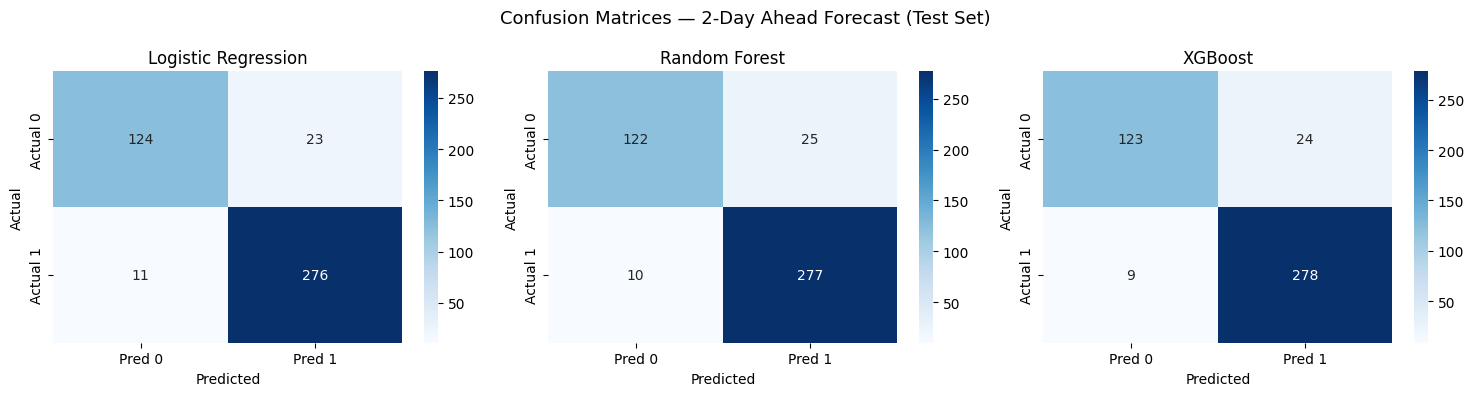

In [43]:
# Confusion Matrices — LR, RF, XGBoost (2-Day Ahead, Test Set)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, r in zip(axes, all_results):
    cm = confusion_matrix(r["y_true"], r["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Actual 0", "Actual 1"])
    ax.set_title(r["name"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(f"Confusion Matrices — {HORIZON}-Day Ahead Forecast (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrices_all_models.png", dpi=150, bbox_inches="tight")
plt.show()


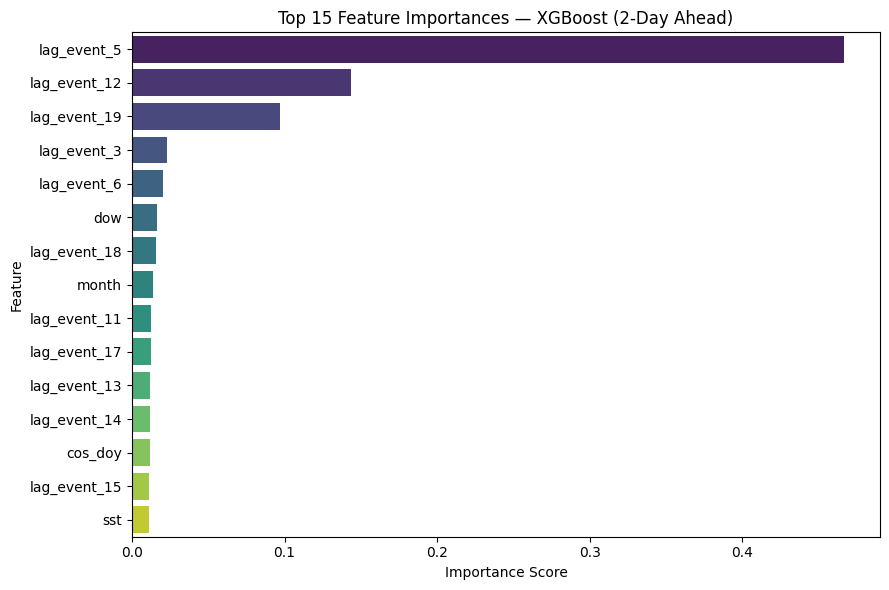

In [45]:
# XGBoost Feature Importance (2-Day Ahead)
fi_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": r_xgb["model"].feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=fi_df.head(15), x="importance", y="feature",
            hue="feature", palette="viridis", legend=False)
plt.title("Top 15 Feature Importances — XGBoost (2-Day Ahead)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance_xgboost_2day.png", dpi=150, bbox_inches="tight")
plt.show()


XGBoost 1-day ahead → AUC=0.9349  Acc=0.9217  Prec=0.9203  Rec=0.9652  F1=0.9422
XGBoost 2-day ahead → AUC=0.9355  Acc=0.9240  Prec=0.9205  Rec=0.9686  F1=0.9440
XGBoost 3-day ahead → AUC=0.9356  Acc=0.9263  Prec=0.9236  Rec=0.9686  F1=0.9456


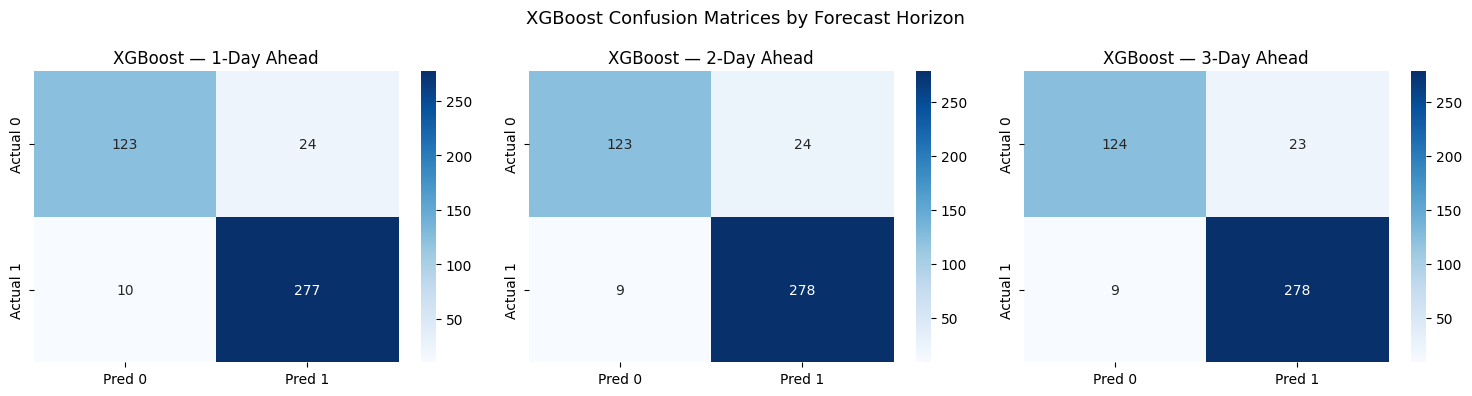

In [46]:
# XGBoost Across 1 / 2 / 3-Day Horizons (70/10/20 split)
xgb_horizons = {}

for h in [1, 2, 3]:
    df_hh = df_fe.copy()
    df_hh["target_future"] = df_hh["has_event"].shift(-h)
    df_hh = df_hh.dropna(subset=feature_cols + ["target_future"]).reset_index(drop=True)

    X_a = df_hh[feature_cols]
    y_a = df_hh["target_future"].astype(int)
    n_h = len(df_hh)

    te_h   = int(n_h * 0.70)
    val_h  = int(n_h * 0.80)

    X_tr_h,  y_tr_h  = X_a.iloc[:te_h],      y_a.iloc[:te_h]
    X_te_h,  y_te_h  = X_a.iloc[val_h:],     y_a.iloc[val_h:]

    m = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.03, max_depth=4,
        subsample=0.9, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss", random_state=0)
    m.fit(X_tr_h, y_tr_h)

    proba_h = m.predict_proba(X_te_h)[:, 1]
    pred_h  = (proba_h > 0.5).astype(int)
    auc_h   = roc_auc_score(y_te_h, proba_h)
    acc_h   = accuracy_score(y_te_h, pred_h)
    prec_h, rec_h, f1_h, _ = precision_recall_fscore_support(y_te_h, pred_h, average="binary")

    xgb_horizons[h] = {
        "auc": auc_h, "acc": acc_h, "prec": prec_h,
        "rec": rec_h, "f1": f1_h,
        "proba": proba_h, "pred": pred_h, "y_true": y_te_h,
        "dates": df_hh["date"].iloc[val_h:].reset_index(drop=True)
    }
    print(f"XGBoost {h}-day ahead → AUC={auc_h:.4f}  Acc={acc_h:.4f}  "
          f"Prec={prec_h:.4f}  Rec={rec_h:.4f}  F1={f1_h:.4f}")

# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h in zip(axes, [1, 2, 3]):
    r = xgb_horizons[h]
    cm = confusion_matrix(r["y_true"], r["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"],
                yticklabels=["Actual 0","Actual 1"])
    ax.set_title(f"XGBoost — {h}-Day Ahead")
plt.suptitle("XGBoost Confusion Matrices by Forecast Horizon", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrices_xgboost_horizons.png", dpi=150, bbox_inches="tight")
plt.show()


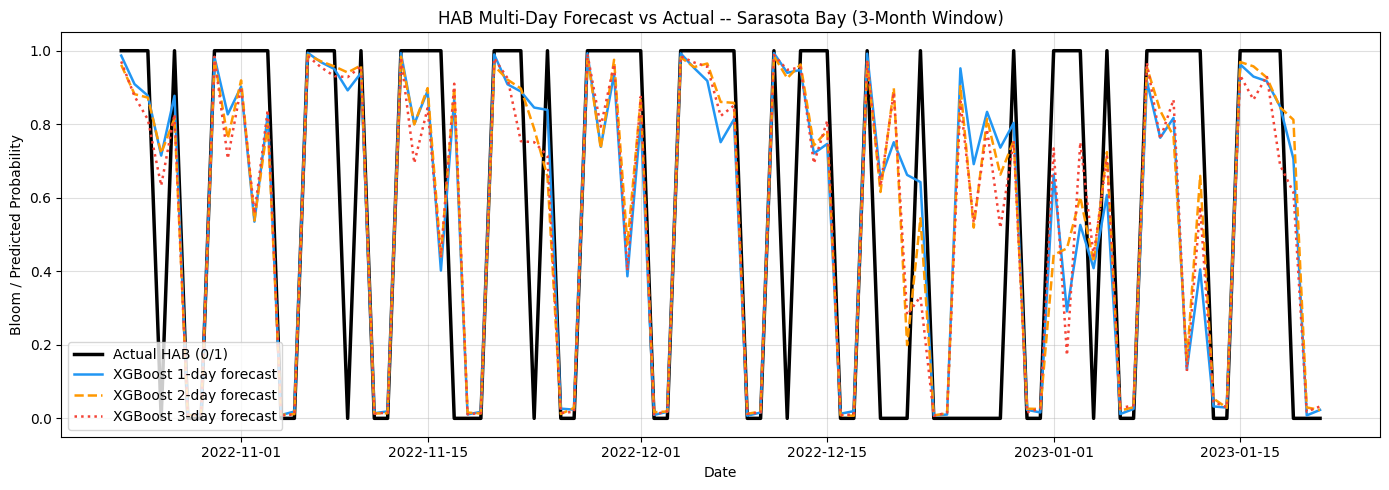

Saved: multiday_forecast_vs_actual.png


In [50]:
# Multi-Day Forecast vs Actual — All 3 Horizons (Figure 3)
import pandas as pd
import matplotlib.pyplot as plt

# Build base dataframe from 1-day horizon results
plot_base = pd.DataFrame({
    "date":   xgb_horizons[1]["dates"],
    "actual": xgb_horizons[1]["y_true"].reset_index(drop=True),
})

# Add predicted probabilities for each horizon
for h in [1, 2, 3]:
    plot_base[f"p_d{h}"] = xgb_horizons[h]["proba"]

# Window: anchor on first bloom day in test set
bloom_days = plot_base[plot_base["actual"] == 1]
if len(bloom_days) > 0:
    start = bloom_days["date"].iloc[0]
    end   = start + pd.Timedelta(days=90)
else:
    top_day = plot_base.sort_values("p_d1", ascending=False).iloc[0]
    start   = top_day["date"] - pd.Timedelta(days=45)
    end     = top_day["date"] + pd.Timedelta(days=45)

mask       = (plot_base["date"] >= start) & (plot_base["date"] <= end)
plot_slice = plot_base[mask].copy()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(plot_slice["date"], plot_slice["actual"],
         label="Actual HAB (0/1)", linewidth=2.5, color="black")

colors    = {1: "#2196F3", 2: "#FF9800", 3: "#F44336"}
linestyle = {1: "-",       2: "--",      3: ":"}
labels    = {1: "XGBoost 1-day forecast",
             2: "XGBoost 2-day forecast",
             3: "XGBoost 3-day forecast"}

for h in [1, 2, 3]:
    plt.plot(plot_slice["date"], plot_slice[f"p_d{h}"],
             label=labels[h], linewidth=1.8,
             linestyle=linestyle[h], color=colors[h])

plt.title("HAB Multi-Day Forecast vs Actual -- Sarasota Bay (3-Month Window)")
plt.xlabel("Date")
plt.ylabel("Bloom / Predicted Probability")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("multiday_forecast_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: multiday_forecast_vs_actual.png")

### LSTM Sequence Model — 2-Day Ahead Forecast
The LSTM uses a **20-day sliding window** of features to predict whether a bloom will occur **2 days ahead**, matching the expanded lag window used in XGBoost.

In [47]:
#  LSTM: SEQ_LEN=20, 2-Day Ahead | 70/10/20 split
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support

SEQ_LEN = 20
HORIZON_LSTM = 2

df_lstm = df_fe.copy()
df_lstm["target_future"] = df_lstm["has_event"].shift(-HORIZON_LSTM)
df_lstm = df_lstm.dropna(subset=feature_cols + ["target_future"]).reset_index(drop=True)

n_lstm = len(df_lstm)
train_end_l = int(n_lstm * 0.70)
val_end_l   = int(n_lstm * 0.80)

# Standardise on train only
scaler   = StandardScaler()
X_sc_tr  = scaler.fit_transform(df_lstm[feature_cols].iloc[:train_end_l])
X_sc_val = scaler.transform(df_lstm[feature_cols].iloc[train_end_l:val_end_l])
X_sc_te  = scaler.transform(df_lstm[feature_cols].iloc[val_end_l:])

X_sc_all = np.vstack([X_sc_tr, X_sc_val, X_sc_te])
y_lstm   = df_lstm["target_future"].astype(int).values

# Build sequences
def make_seqs(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_seqs(X_sc_all, y_lstm, SEQ_LEN)

# Recompute split indices after sequence creation
seq_train_end = train_end_l - SEQ_LEN
seq_val_end   = val_end_l   - SEQ_LEN

X_tr_s,  y_tr_s  = X_seq[:seq_train_end],             y_seq[:seq_train_end]
X_val_s, y_val_s = X_seq[seq_train_end:seq_val_end],   y_seq[seq_train_end:seq_val_end]
X_te_s,  y_te_s  = X_seq[seq_val_end:],               y_seq[seq_val_end:]

print(f"LSTM sequences — Train: {len(X_tr_s)} | Val: {len(X_val_s)} | Test: {len(X_te_s)}")

# Build model
lstm_model = Sequential([
    Input(shape=(SEQ_LEN, len(feature_cols))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1,  activation="sigmoid"),
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

history = lstm_model.fit(
    X_tr_s, y_tr_s,
    validation_data=(X_val_s, y_val_s),   # explicit val set — NOT validation_split
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

# Evaluate on test set
proba_lstm = lstm_model.predict(X_te_s).flatten()
pred_lstm  = (proba_lstm > 0.5).astype(int)
lstm_auc   = roc_auc_score(y_te_s, proba_lstm)
lstm_acc   = accuracy_score(y_te_s, pred_lstm)
lstm_prec, lstm_rec, lstm_f1, _ = precision_recall_fscore_support(
    y_te_s, pred_lstm, average="binary")

r_lstm = {
    "name": "LSTM", "proba": proba_lstm, "pred": pred_lstm,
    "y_true": y_te_s, "acc": lstm_acc, "prec": lstm_prec,
    "rec": lstm_rec, "f1": lstm_f1, "auc": lstm_auc
}

print(f"\nLSTM Test — AUC={lstm_auc:.4f}  Acc={lstm_acc:.4f}  "
      f"Prec={lstm_prec:.4f}  Rec={lstm_rec:.4f}  F1={lstm_f1:.4f}")
print(classification_report(y_te_s, pred_lstm))


LSTM sequences — Train: 1496 | Val: 217 | Test: 434
Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.6544 - loss: 0.6387 - val_accuracy: 0.6313 - val_loss: 0.6461
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6791 - loss: 0.5984 - val_accuracy: 0.6636 - val_loss: 0.5836
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7747 - loss: 0.5298 - val_accuracy: 0.8618 - val_loss: 0.4717
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8309 - loss: 0.4598 - val_accuracy: 0.8341 - val_loss: 0.4242
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8469 - loss: 0.3989 - val_accuracy: 0.8802 - val_loss: 0.3487
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8656 - loss: 0.3678 - val_accuracy: 0.8710 - val_loss: 0.3296
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8703 - loss: 0.3474 - val_accuracy: 0.8802 - val_loss: 0.3189
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accur

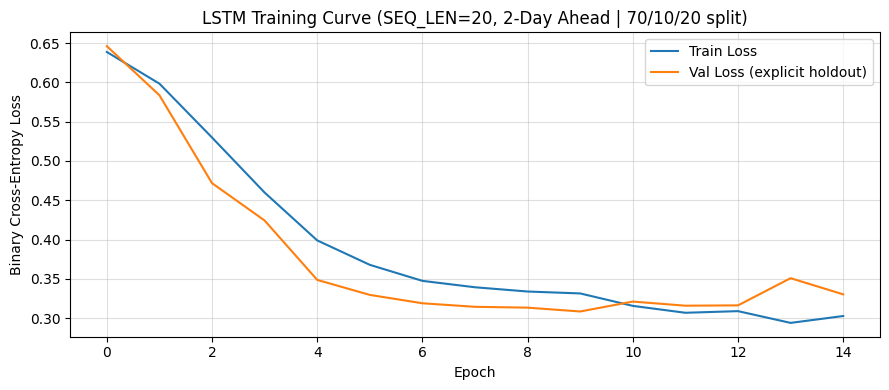

In [48]:
# LSTM Training / Validation Loss Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss (explicit holdout)")
plt.title(f"LSTM Training Curve (SEQ_LEN={SEQ_LEN}, {HORIZON_LSTM}-Day Ahead | 70/10/20 split)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("lstm_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [49]:
# Final Model Comparison Table — All 4 Models | 70/10/20 Split
import pandas as pd

rows = all_results + [r_lstm]

summary = pd.DataFrame({
    "Model":      [r["name"] for r in rows],
    "Accuracy":   [f"{r['acc']*100:.1f}" for r in rows],
    "Precision":  [f"{r['prec']*100:.1f}" for r in rows],
    "Recall":     [f"{r['rec']*100:.1f}" for r in rows],
    "F1-Score":   [f"{r['f1']*100:.1f}" for r in rows],
    "AUC":        [f"{r['auc']*100:.2f}" for r in rows],
})

print("="*70)
print("Model Comparison — 2-Day Ahead | 70/10/20 Chronological Split")
print("Test set performance only (validation set used for tuning/early stopping)")
print("="*70)
print(summary.to_string(index=False))
summary


Model Comparison — 2-Day Ahead | 70/10/20 Chronological Split
Test set performance only (validation set used for tuning/early stopping)
              Model Accuracy Precision Recall F1-Score   AUC
Logistic Regression     92.2      92.3   96.2     94.2 93.39
      Random Forest     91.9      91.7   96.5     94.1 94.46
            XGBoost     92.4      92.1   96.9     94.4 93.55
               LSTM     92.6      91.5   97.9     94.6 93.38


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,92.2,92.3,96.2,94.2,93.39
1,Random Forest,91.9,91.7,96.5,94.1,94.46
2,XGBoost,92.4,92.1,96.9,94.4,93.55
3,LSTM,92.6,91.5,97.9,94.6,93.38
